In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
# STEP 1 — Environment & dataset sanity check (run first)

import os
import sys
import warnings
warnings.filterwarnings("ignore")   

# Reduce a lot of noisy logs from TF/transformers/etc.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["HF_HUB_DISABLE_PROGRESS_BAR"] = "1"
os.environ["WANDB_DISABLED"] = "true"

# Import common libs and report versions 
def safe_import(name, as_name=None):
    try:
        module = __import__(name)
        return module
    except Exception as e:
        return None

import importlib
import traceback

libs = {
    "python": sys.version.splitlines()[0],
    "numpy": None,
    "pandas": None,
    "scipy": None,
    "librosa": None,
    "torch": None,
    "transformers": None,
    "sklearn": None,
    "lightgbm": None,
    "xgboost": None,
    "tqdm": None
}

for k in list(libs.keys())[1:]:
    try:
        mod = importlib.import_module(k)
        libs[k] = getattr(mod, "__version__", str(mod))
    except Exception:
        libs[k] = "NOT INSTALLED / import error"

# GPU check
gpu_available = False
gpu_name = None
try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        gpu_name = torch.cuda.get_device_name(0)
except Exception:
    pass

# Paths to check
ROOT = "/kaggle/input/shl-intern-hiring-assessment-2025"
CSV_DIR = os.path.join(ROOT, "dataset", "csvs")
AUDIO_DIR = os.path.join(ROOT, "dataset", "audios")
TRAIN_AUDIO_DIR = os.path.join(AUDIO_DIR, "train")
TEST_AUDIO_DIR  = os.path.join(AUDIO_DIR, "test")

# Prepare working dir
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

# File checks
def exists_and_count(path, ext=None):
    ok = os.path.exists(path)
    count = 0
    sample = []
    if ok:
        if os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for f in files:
                    if ext is None or f.lower().endswith(ext):
                        count += 1
                        if len(sample) < 10:
                            sample.append(f)
        else:
            count = 1
            sample = [os.path.basename(path)]
    return ok, count, sample

train_csv = os.path.join(CSV_DIR, "train.csv")
test_csv  = os.path.join(CSV_DIR, "test.csv")
sample_sub = os.path.join(CSV_DIR, "sample_submission.csv")

train_csv_ok, _, _ = exists_and_count(train_csv)
test_csv_ok, _, _ = exists_and_count(test_csv)
sample_sub_ok, _, _ = exists_and_count(sample_sub)
train_audio_ok, train_audio_count, train_audio_sample = exists_and_count(TRAIN_AUDIO_DIR, ext=".wav")
test_audio_ok, test_audio_count, test_audio_sample = exists_and_count(TEST_AUDIO_DIR, ext=".wav")

# Print a concise report 
print("Notebook environment ready.")
print("Output directory:", OUT_DIR)
print("GPU available:", gpu_available, ("- " + gpu_name) if gpu_name else "")

print("\nKey library versions (if 'NOT INSTALLED' appears, we'll handle it next):")
for k,v in libs.items():
    print(f"  {k:12s}: {v}")

print("\nDataset checks:")
print(f"  train.csv exists?        {train_csv_ok}")
print(f"  test.csv exists?         {test_csv_ok}")
print(f"  sample_submission exists?{sample_sub_ok}")
print(f"  TRAIN_AUDIO exists?      {train_audio_ok}  (# .wav = {train_audio_count})")
print(f"  TEST_AUDIO exists?       {test_audio_ok}  (# .wav = {test_audio_count})")

if train_audio_count > 0:
    print("\n  Example train filenames (first 8):", train_audio_sample[:8])
if test_audio_count > 0:
    print("  Example test filenames  (first 8):", test_audio_sample[:8])

print("\nIf the above shows missing files or missing libs, tell me the printed lines exactly and I will adjust.")
print("If everything looks OK, reply with the printed output and I'll give Step 2 (WavLM-Large TTA5 extraction, memory-safe, no warnings).")


Notebook environment ready.
Output directory: /kaggle/working
GPU available: True - Tesla T4

Key library versions (if 'NOT INSTALLED' appears, we'll handle it next):
  python      : 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
  numpy       : 1.26.4
  pandas      : 2.2.3
  scipy       : 1.15.3
  librosa     : 0.11.0
  torch       : 2.6.0+cu124
  transformers: 4.53.3
  sklearn     : 1.2.2
  lightgbm    : 4.6.0
  xgboost     : 2.0.3
  tqdm        : 4.67.1

Dataset checks:
  train.csv exists?        True
  test.csv exists?         True
  sample_submission exists?False
  TRAIN_AUDIO exists?      True  (# .wav = 409)
  TEST_AUDIO exists?       True  (# .wav = 197)

  Example train filenames (first 8): ['audio_49.wav', 'audio_77_2.wav', 'audio_90.wav', 'audio_77.wav', 'audio_66.wav', 'audio_54.wav', 'audio_237.wav', 'audio_42.wav']
  Example test filenames  (first 8): ['audio_49.wav', 'audio_67_1.wav', 'audio_90.wav', 'audio_77.wav', 'audio_20_1.wav', 'audio_66.wav', 'audio_54.wav', '

In [12]:
# WavLM-Large TTA5 extraction 
import os, gc, warnings
import numpy as np, pandas as pd, librosa, torch
from tqdm.auto import tqdm
from transformers import AutoFeatureExtractor, AutoModel, logging as hf_logging

# minimize noisy prints from transformers
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

OUT_DIR = "/kaggle/working"
DATA_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025"
TRAIN_CSV = os.path.join(DATA_DIR, "dataset/csvs/train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "dataset/csvs/test.csv")
TRAIN_AUDIO = os.path.join(DATA_DIR, "dataset/audios/train")
TEST_AUDIO  = os.path.join(DATA_DIR, "dataset/audios/test")
os.makedirs(OUT_DIR, exist_ok=True)

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
train_df["file_path"] = train_df["filename"].apply(lambda f: f"{TRAIN_AUDIO}/{f}.wav")
test_df["file_path"]  = test_df["filename"].apply(lambda f: f"{TEST_AUDIO}/{f}.wav")

device = "cuda" if torch.cuda.is_available() else "cpu"
ngpu = torch.cuda.device_count()
print(f"Using device: {device}, GPUs available: {ngpu}")

MODEL_NAME = "microsoft/wavlm-large"
print("Loading model (fp32):", MODEL_NAME)
fe = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

# If more than one GPU, wrap in DataParallel (simple, no distributed setup)
if ngpu > 1:
    model = torch.nn.DataParallel(model)
    print("Wrapped model with DataParallel -> will use multiple GPUs")

# --- augmentations ---
def add_noise(y, scale=0.005):
    return y + np.random.randn(len(y)) * scale

def stretch(y, rate=1.03):
    try: return librosa.effects.time_stretch(y, rate)
    except: return y

def pitch_shift(y, sr=16000, n_steps=1):
    try: return librosa.effects.pitch_shift(y, sr, n_steps=n_steps)
    except: return y

# --- embed as batch of waveform variants (list input to feature extractor) ---
def embed_tta_batch(y_list, sr=16000):
    # y_list: list of numpy arrays (the TTA variants) — fe handles list batching and padding
    inputs = fe(y_list, sampling_rate=sr, return_tensors="pt", padding=True)
    input_values = inputs.input_values.to(device)  # shape: (batch, seq_len)
    with torch.no_grad():
        out = model(input_values)  # DataParallel or single-GPU
        # auto-model returns object with last_hidden_state (B, T, H)
        last = out.last_hidden_state  # tensor on GPU
        vecs = last.mean(dim=1).cpu().numpy()  # (B, H) -> numpy on CPU
    return vecs  # shape (batch, H)

def tta5_emb_from_path(path):
    y, sr = librosa.load(path, sr=16000, mono=True)
    if (y is None) or (y.size == 0):
        return None
    v0 = y
    v1 = add_noise(y, 0.005)
    v2 = stretch(y, 1.03)
    v3 = pitch_shift(y, sr, -1)
    v4 = pitch_shift(y, sr, 1)
    batch = [v0, v1, v2, v3, v4]
    try:
        vecs = embed_tta_batch(batch, sr=16000)  # (5, H)
        return vecs.mean(axis=0)                 # mean across TTA variants -> (H,)
    except Exception as e:
        print("Embed error for", path, "->", str(e))
        return None

def extract_and_save(df, outname):
    embs = []
    bad = []
    for p in tqdm(df["file_path"].tolist(), desc=outname):
        if not os.path.exists(p):
            bad.append((p, "missing"))
            embs.append(None)
            continue
        e = tta5_emb_from_path(p)
        if e is None:
            bad.append((p, "failed"))
        embs.append(e)
        # free mem frequently
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # build array with proper width
    valid = [e for e in embs if e is not None]
    if len(valid) == 0:
        raise RuntimeError("No valid embeddings extracted.")
    H = valid[0].shape[0]
    arr = np.zeros((len(embs), H), dtype=np.float32)
    for i,e in enumerate(embs):
        if e is not None:
            arr[i, :e.shape[0]] = e
    outpath = os.path.join(OUT_DIR, f"{outname}.npy")
    np.save(outpath, arr)
    return arr, bad

print("Extracting WavLM train (TTA5, batched per-file)...")
train_emb, bad_train = extract_and_save(train_df, "wavlm_train_tta5")
print("bad_train count:", len(bad_train))

print("Extracting WavLM test (TTA5, batched per-file)...")
test_emb, bad_test = extract_and_save(test_df, "wavlm_test_tta5")
print("bad_test count:", len(bad_test))

print("Saved shapes:", train_emb.shape, test_emb.shape)
print("Zero rows train:", int((train_emb==0).all(axis=1).sum()))
print("Zero rows test :", int((test_emb==0).all(axis=1).sum()))

# sample stats
print("Sample mean/std:", float(train_emb[0].mean()), float(train_emb[0].std()))

Using device: cuda, GPUs available: 2
Loading model (fp32): microsoft/wavlm-large
Wrapped model with DataParallel -> will use multiple GPUs
Extracting WavLM train (TTA5, batched per-file)...


wavlm_train_tta5:   0%|          | 0/409 [00:00<?, ?it/s]

bad_train count: 0
Extracting WavLM test (TTA5, batched per-file)...


wavlm_test_tta5:   0%|          | 0/197 [00:00<?, ?it/s]

bad_test count: 0
Saved shapes: (409, 1024) (197, 1024)
Zero rows train: 0
Zero rows test : 0
Sample mean/std: 0.00016272912034764886 0.052399441599845886


In [17]:
# STEP 3 — WavLM models (Ridge + LightGBM + XGBoost) + Stacking


import os, gc, io, contextlib
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

from lightgbm import LGBMRegressor, early_stopping
import xgboost as xgb
import torch

OUT_DIR = "/kaggle/working"
DATA_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025"
TRAIN_CSV = os.path.join(DATA_DIR, "dataset", "csvs", "train.csv")

# 1) Load labels and WavLM embeddings
train_df = pd.read_csv(TRAIN_CSV)
y = train_df["label"].values.astype(float)

W_train = np.load(os.path.join(OUT_DIR, "wavlm_train_tta5.npy"))
W_test  = np.load(os.path.join(OUT_DIR, "wavlm_test_tta5.npy"))
print("Loaded W shapes:", W_train.shape, W_test.shape)

# Scale embeddings
scaler = StandardScaler()
X = scaler.fit_transform(W_train)
X_test = scaler.transform(W_test)

NFOLDS = 5
kf = KFold(n_splits=NFOLDS, shuffle=True, random_state=42)

# ----------------------------------------------------
# 2) Ridge baseline (single strong linear model)
# ----------------------------------------------------
print("\n=== Ridge CV (baseline, with Pearson) ===")
alphas = [10.0, 50.0, 100.0]
ridge_oof = None
ridge_test = None
best_alpha = None
best_rmse = 1e9

for alpha in alphas:
    oof = np.zeros(len(X))
    test_folds = np.zeros((X_test.shape[0], NFOLDS))
    rmses, pears = [], []

    for fold, (tr, va) in enumerate(kf.split(X), start=1):
        model = Ridge(alpha=alpha)
        model.fit(X[tr], y[tr])
        pv = model.predict(X[va])
        pt = model.predict(X_test)

        oof[va] = pv
        test_folds[:, fold-1] = pt

        rmse = mean_squared_error(y[va], pv, squared=False)
        corr = pearsonr(y[va], pv)[0]
        rmses.append(rmse)
        pears.append(corr)
        print(f" alpha={alpha:.0f} fold{fold} RMSE: {rmse:.6f}, Pearson: {corr:.6f}")

    avg_rmse = float(np.mean(rmses))
    avg_pear = float(np.mean(pears))
    print(f" alpha={alpha:.0f} Average CV RMSE: {avg_rmse:.6f}, Average CV Pearson: {avg_pear:.6f}\n")

    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_alpha = alpha
        ridge_oof = oof.copy()
        ridge_test = test_folds.mean(axis=1)

ridge_oof_rmse = mean_squared_error(y, ridge_oof, squared=False)
ridge_oof_pear = pearsonr(y, ridge_oof)[0]
print(f"Best Ridge alpha (by RMSE): {best_alpha}")
print(f"Ridge OOF RMSE (train): {ridge_oof_rmse:.6f}, Pearson: {ridge_oof_pear:.6f}")

np.save(os.path.join(OUT_DIR, "oof_ridge_wavlm_step3.npy"), ridge_oof)
np.save(os.path.join(OUT_DIR, "test_ridge_wavlm_step3.npy"), ridge_test)

# ----------------------------------------------------
# 3) LightGBM  with Pearson
# ----------------------------------------------------
print("\n=== LightGBM CV (clean output, with Pearson) ===")

oof_lgb = np.zeros(len(X))
test_lgb = np.zeros(X_test.shape[0])

lgb_params = {
    "n_estimators": 3000,
    "learning_rate": 0.01,
    "num_leaves": 128,
    "colsample_bytree": 0.8,
    "subsample": 0.9,
    "random_state": 42,
    "verbosity": -1,
    "device": "gpu" if torch.cuda.is_available() else "cpu",
}

lgb_rmses, lgb_pears = [], []

for fold, (tr, va) in enumerate(kf.split(X), start=1):
    model = LGBMRegressor(**lgb_params)
    # capture C-level warnings printed to stderr
    stderr_buf = io.StringIO()
    with contextlib.redirect_stderr(stderr_buf):
        model.fit(
            X[tr], y[tr],
            eval_set=[(X[va], y[va])],
            eval_metric="rmse",
            callbacks=[early_stopping(stopping_rounds=200, verbose=False)],
        )

    pv = model.predict(X[va])
    pt = model.predict(X_test)

    oof_lgb[va] = pv
    test_lgb += pt / NFOLDS

    rmse = mean_squared_error(y[va], pv, squared=False)
    corr = pearsonr(y[va], pv)[0]
    lgb_rmses.append(rmse)
    lgb_pears.append(corr)
    print(f" LGB fold{fold} RMSE: {rmse:.6f}, Pearson: {corr:.6f}")

lgb_oof_rmse = mean_squared_error(y, oof_lgb, squared=False)
lgb_oof_pear = pearsonr(y, oof_lgb)[0]
print(f"LightGBM OOF RMSE (train): {lgb_oof_rmse:.6f}, Pearson: {lgb_oof_pear:.6f}")

np.save(os.path.join(OUT_DIR, "oof_lgb_wavlm_step3.npy"), oof_lgb)
np.save(os.path.join(OUT_DIR, "test_lgb_wavlm_step3.npy"), test_lgb)
print("Saved LGB OOF/test arrays.")

# ----------------------------------------------------
# 4) XGBoost  with Pearson
# ----------------------------------------------------
print("\n=== XGBoost CV (quiet, with Pearson) ===")

oof_xgb = np.zeros(len(X))
test_xgb = np.zeros(X_test.shape[0])

xgb_params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.01,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "eval_metric": "rmse",
    "seed": 42,
    "verbosity": 0,
}

xgb_rmses, xgb_pears = [], []

for fold, (tr, va) in enumerate(kf.split(X), start=1):
    dtr = xgb.DMatrix(X[tr], label=y[tr])
    dva = xgb.DMatrix(X[va], label=y[va])
    dte = xgb.DMatrix(X_test)

    bst = xgb.train(
        xgb_params,
        dtr,
        num_boost_round=4000,
        evals=[(dva, "valid")],
        early_stopping_rounds=200,
        verbose_eval=False,
    )

    pv = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
    pt = bst.predict(dte, iteration_range=(0, bst.best_iteration + 1))

    oof_xgb[va] = pv
    test_xgb += pt / NFOLDS

    rmse = mean_squared_error(y[va], pv, squared=False)
    corr = pearsonr(y[va], pv)[0]
    xgb_rmses.append(rmse)
    xgb_pears.append(corr)
    print(f" XGB fold{fold} RMSE: {rmse:.6f}, Pearson: {corr:.6f}")

xgb_oof_rmse = mean_squared_error(y, oof_xgb, squared=False)
xgb_oof_pear = pearsonr(y, oof_xgb)[0]
print(f"XGBoost OOF RMSE (train): {xgb_oof_rmse:.6f}, Pearson: {xgb_oof_pear:.6f}")

np.save(os.path.join(OUT_DIR, "oof_xgb_wavlm_step3.npy"), oof_xgb)
np.save(os.path.join(OUT_DIR, "test_xgb_wavlm_step3.npy"), test_xgb)

# ----------------------------------------------------
# 5) Simple stacking: Ridge meta on [ridge, lgb, xgb]
# ----------------------------------------------------
print("\n=== Stacking meta (LinearRegression) ===")

stack_train = np.vstack([ridge_oof, oof_lgb, oof_xgb]).T
stack_test  = np.vstack([ridge_test, test_lgb, test_xgb]).T

meta = LinearRegression()
meta.fit(stack_train, y)
stack_oof = meta.predict(stack_train)
stack_pred = meta.predict(stack_test)

stack_rmse = mean_squared_error(y, stack_oof, squared=False)
stack_pear = pearsonr(y, stack_oof)[0]
print(f"Stack OOF RMSE (train): {stack_rmse:.6f}, Pearson: {stack_pear:.6f}")
print("Meta coefficients:", meta.coef_.tolist(), "Intercept:", float(meta.intercept_))

# Build submission
test_df = pd.read_csv(os.path.join(DATA_DIR, "dataset", "csvs", "test.csv"))
sub = test_df.copy()
sub["label"] = stack_pred
sub_path = os.path.join(OUT_DIR, "submission_wavlm_step3.csv")
sub.to_csv(sub_path, index=False)
print("\nSaved submission:", sub_path)

gc.collect()

Loaded W shapes: (409, 1024) (197, 1024)

=== Ridge CV (baseline, with Pearson) ===
 alpha=10 fold1 RMSE: 0.708361, Pearson: 0.578403
 alpha=10 fold2 RMSE: 0.648429, Pearson: 0.536149
 alpha=10 fold3 RMSE: 0.707994, Pearson: 0.674962
 alpha=10 fold4 RMSE: 0.653576, Pearson: 0.575941
 alpha=10 fold5 RMSE: 0.664674, Pearson: 0.582857
 alpha=10 Average CV RMSE: 0.676607, Average CV Pearson: 0.589662

 alpha=50 fold1 RMSE: 0.643468, Pearson: 0.614578
 alpha=50 fold2 RMSE: 0.580841, Pearson: 0.589358
 alpha=50 fold3 RMSE: 0.630386, Pearson: 0.711778
 alpha=50 fold4 RMSE: 0.584584, Pearson: 0.620111
 alpha=50 fold5 RMSE: 0.616636, Pearson: 0.625402
 alpha=50 Average CV RMSE: 0.611183, Average CV Pearson: 0.632245

 alpha=100 fold1 RMSE: 0.620905, Pearson: 0.629140
 alpha=100 fold2 RMSE: 0.564415, Pearson: 0.606157
 alpha=100 fold3 RMSE: 0.603131, Pearson: 0.726714
 alpha=100 fold4 RMSE: 0.564488, Pearson: 0.632290
 alpha=100 fold5 RMSE: 0.600089, Pearson: 0.641572
 alpha=100 Average CV RMSE:

401

In [19]:
#  Diagnostics & comparison plots (clean + safe)
import os, contextlib, io, warnings, gc
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

OUT_DIR = "/kaggle/working"
TRAIN_CSV = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/train.csv"

# ---- Safe loader (only loads .npy files) ----
def safe_load(path):
    if not os.path.exists(path): 
        return None
    if not path.endswith(".npy"):
        return None   # <---- FIX: do NOT load CSV
    return np.load(path, allow_pickle=True)

# Load true labels
train_df = pd.read_csv(TRAIN_CSV)
y_true = train_df["label"].values.astype(float)

# Load OOF arrays
ridge_oof = safe_load(os.path.join(OUT_DIR, "oof_ridge_wavlm_step3.npy"))
lgb_oof   = safe_load(os.path.join(OUT_DIR, "oof_lgb_wavlm_step3.npy"))
xgb_oof   = safe_load(os.path.join(OUT_DIR, "oof_xgb_wavlm_step3.npy"))

stack_oof = safe_load(os.path.join(OUT_DIR, "oof_stack_step3.npy"))
if stack_oof is None:
    # try alternate names
    for name in ["oof_stack.npy", "oof_ridge_wavlm_tta5.npy"]:
        tmp = safe_load(os.path.join(OUT_DIR, name))
        if tmp is not None and tmp.shape[0] == y_true.shape[0]:
            stack_oof = tmp
            break

# Build dictionary of available models
models = {}
if ridge_oof is not None: models["Ridge"] = ridge_oof
if lgb_oof   is not None: models["LightGBM"] = lgb_oof
if xgb_oof   is not None: models["XGBoost"] = xgb_oof
if stack_oof is not None: models["Stack"] = stack_oof

if len(models) == 0:
    raise RuntimeError("No OOF arrays found — ensure Step 3 saved oof_*_wavlm_step3.npy")

# ---- Compute RMSE & Pearson for each model ----
rows = []
for name, pred in models.items():
    rmse = mean_squared_error(y_true, pred, squared=False)
    pear = pearsonr(y_true, pred)[0]
    rows.append((name, rmse, pear))

metrics_df = pd.DataFrame(rows, columns=["Model","OOF_RMSE","OOF_Pearson"]).sort_values("OOF_RMSE")

print("OOF metrics:")
print(metrics_df.to_string(index=False))

# ---- Plots directory ----
fig_dir = OUT_DIR
os.makedirs(fig_dir, exist_ok=True)

# ---- Plot 1: OOF vs True ----
plt.figure(figsize=(12,8))
for i, (name, pred) in enumerate(list(models.items())[:4], start=1):
    plt.subplot(2,2,i)
    plt.scatter(y_true, pred, s=8, alpha=0.6)
    mn, mx = min(y_true.min(), pred.min()), max(y_true.max(), pred.max())
    plt.plot([mn,mx],[mn,mx], "--", linewidth=1)
    plt.title(f"{name} (RMSE={mean_squared_error(y_true,pred,squared=False):.3f})")
plt.tight_layout()
p1 = os.path.join(fig_dir, "plot_oof_vs_true.png")
plt.savefig(p1, dpi=150)
plt.close()

# ---- Plot 2: residuals ----
best_model = metrics_df.iloc[0]["Model"]
pred_best = models[best_model]
resid = y_true - pred_best

plt.figure(figsize=(6,4))
plt.scatter(pred_best, resid, s=10, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title(f"{best_model} Residuals (OOF)")
plt.tight_layout()
p2 = os.path.join(fig_dir, "plot_residuals.png")
plt.savefig(p2, dpi=150)
plt.close()

# ---- Plot 3: residual histogram ----
plt.figure(figsize=(6,4))
plt.hist(resid, bins=40)
plt.title(f"{best_model} Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
p3 = os.path.join(fig_dir, "plot_residual_hist.png")
plt.savefig(p3, dpi=150)
plt.close()

print("\nSaved plots:")
print(" ", p1)
print(" ", p2)
print(" ", p3)

gc.collect()

OOF metrics:
   Model  OOF_RMSE  OOF_Pearson
   Ridge  0.591012     0.654638
LightGBM  0.615163     0.596258
 XGBoost  0.616890     0.600190

Saved plots:
  /kaggle/working/plot_oof_vs_true.png
  /kaggle/working/plot_residuals.png
  /kaggle/working/plot_residual_hist.png


41

In [20]:
#  Blend weights search (maximize OOF Pearson) + shrink/trick, save submissions
import os, warnings, gc, numpy as np, pandas as pd
from itertools import product
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

OUT_DIR = "/kaggle/working"
DATA_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

# safe loader for .npy
def safe_npy(p):
    if not os.path.exists(p):
        return None
    return np.load(p, allow_pickle=True)

# load true labels
train_df = pd.read_csv(TRAIN_CSV)
y_true = train_df["label"].values.astype(float)

# load OOF arrays & test preds (try multiple common filenames)
def find_and_load(prefixes):
    arr = {}
    for name in prefixes:
        p = os.path.join(OUT_DIR, name)
        if os.path.exists(p):
            arr[name] = safe_npy(p)
    return arr

oof_candidates = find_and_load([
    "oof_ridge_wavlm_step3.npy", "oof_ridge_wavlm_tta5.npy", "oof_ridge_tta5.npy",
    "oof_lgb_wavlm_step3.npy", "oof_lgb_wavlm_tta5.npy", "oof_lgb_tta5.npy",
    "oof_xgb_wavlm_step3.npy", "oof_xgb_wavlm_tta5.npy", "oof_xgb_tta5.npy",
    "oof_ridge.npy", "oof_lgb.npy", "oof_xgb.npy"
])

test_candidates = find_and_load([
    "test_ridge_wavlm_step3.npy", "test_ridge_wavlm_tta5.npy", "test_ridge_tta5.npy",
    "test_lgb_wavlm_step3.npy", "test_lgb_wavlm_tta5.npy", "test_lgb_tta5.npy",
    "test_xgb_wavlm_step3.npy", "test_xgb_wavlm_tta5.npy", "test_xgb_tta5.npy",
    "test_ridge.npy", "test_lgb.npy", "test_xgb.npy"
])

# Map friendly names -> arrays (prefer wavlm_step3 names if present)
def pick(arr_dict, keys):
    for k in keys:
        if k in arr_dict:
            return arr_dict[k]
    return None

ridge_oof = pick(oof_candidates, [k for k in oof_candidates.keys() if "ridge" in k.lower()])
lgb_oof   = pick(oof_candidates, [k for k in oof_candidates.keys() if "lgb" in k.lower()])
xgb_oof   = pick(oof_candidates, [k for k in oof_candidates.keys() if "xgb" in k.lower()])

ridge_test = pick(test_candidates, [k for k in test_candidates.keys() if "ridge" in k.lower()])
lgb_test   = pick(test_candidates, [k for k in test_candidates.keys() if "lgb" in k.lower()])
xgb_test   = pick(test_candidates, [k for k in test_candidates.keys() if "xgb" in k.lower()])

# require at least ridge + one other
available = {}
if ridge_oof is not None:
    available['ridge'] = (ridge_oof, ridge_test)
if lgb_oof is not None:
    available['lgb'] = (lgb_oof, lgb_test)
if xgb_oof is not None:
    available['xgb'] = (xgb_oof, xgb_test)

if len(available) < 2:
    raise RuntimeError("Need at least two model OOF arrays present in /kaggle/working to run blending. Found: " + ", ".join(available.keys()))

# align shapes check
n = y_true.shape[0]
for k,(o,t) in available.items():
    if o.shape[0] != n:
        raise RuntimeError(f"OOF length mismatch for {k}: expected {n}, got {o.shape[0]}")

# Create list of models and arrays
model_keys = list(available.keys())
oof_stack = np.vstack([available[k][0] for k in model_keys]).T
test_stack = None
# check test arrays exist -> stack test predictions
if all(available[k][1] is not None for k in model_keys):
    test_stack = np.vstack([available[k][1] for k in model_keys]).T
else:
    # if test arrays missing for some models, will still create submission from best oof blend but test preds may be incomplete
    test_stack = None

print("Blend candidates:", model_keys)
print("OOF shape:", oof_stack.shape, "Test stack:", None if test_stack is None else test_stack.shape)
print()

# Grid search weights coarse -> fine (constrained to sum=1)
best = {"pear": -9, "rmse": 9, "weights": None, "pred": None}

# coarse grid (step 0.1 over 3 models or 2 models)
steps_coarse = np.linspace(0,1,11)
if len(model_keys) == 2:
    A, B = 0,1
    for w in steps_coarse:
        wts = [0]*2
        wts[A] = w
        wts[B] = 1-w
        pred = oof_stack.dot(np.array(wts))
        pear = pearsonr(y_true, pred)[0]
        rmse = mean_squared_error(y_true, pred, squared=False)
        if pear > best["pear"]:
            best.update({"pear":pear, "rmse":rmse, "weights":wts, "pred":pred})
else:
    # 3-model search
    for w1 in steps_coarse:
        for w2 in steps_coarse:
            w3 = 1.0 - w1 - w2
            if w3 < 0 or w3 > 1: 
                continue
            wts = [w1,w2,w3]
            pred = oof_stack.dot(np.array(wts))
            pear = pearsonr(y_true, pred)[0]
            rmse = mean_squared_error(y_true, pred, squared=False)
            if pear > best["pear"]:
                best.update({"pear":pear, "rmse":rmse, "weights":wts, "pred":pred})

# refine around best (small steps)
best_w = best["weights"]
if best_w is None:
    raise RuntimeError("Failed to find blend weights.")
# make small refinements
fine_range = np.linspace(-0.1,0.1,21)
best2 = best.copy()
if len(model_keys) == 2:
    for delta in fine_range:
        w0 = best_w[0] + delta
        w1 = 1 - w0
        if w0 < 0 or w0>1: continue
        wts = [w0,w1]
        pred = oof_stack.dot(np.array(wts))
        pear = pearsonr(y_true, pred)[0]
        rmse = mean_squared_error(y_true, pred, squared=False)
        if pear > best2["pear"]:
            best2.update({"pear":pear, "rmse":rmse, "weights":wts, "pred":pred})
else:
    for d1 in fine_range:
        for d2 in fine_range:
            wts = np.array(best_w) + np.array([d1,d2, -(d1+d2)])
            if np.any(wts < 0) or np.any(wts>1): continue
            pred = oof_stack.dot(wts)
            pear = pearsonr(y_true, pred)[0]
            rmse = mean_squared_error(y_true, pred, squared=False)
            if pear > best2["pear"]:
                best2.update({"pear":pear, "rmse":rmse, "weights":wts.tolist(), "pred":pred})

# final chosen blend:
chosen = best2
print("Best blend by OOF Pearson:")
for k,w in zip(model_keys, chosen["weights"]):
    print(f"  {k}: {w:.4f}")
print(f"OOF RMSE: {chosen['rmse']:.6f}  OOF Pearson: {chosen['pear']:.6f}")
print()

# Optional: small shrink towards mean improves Pearson sometimes.
# We'll try shrink factors in [0.9 .. 1.06] and a small bias shift to maximize Pearson.
mu = y_true.mean()
best_shrink = {"pear": chosen["pear"], "rmse": chosen["rmse"], "factor":1.0, "bias":0.0, "pred": chosen["pred"]}
factors = np.concatenate([np.linspace(0.90,1.00,11), np.linspace(1.00,1.06,7)])
biases = np.linspace(-0.15,0.15,31)   # small bias shift
pred_base = chosen["pred"]
for f in factors:
    p = mu + f * (pred_base - mu)   # shrink towards mean
    # quick check bias only if better
    for b in [0.0]:  # we try bias in a shallow loop to keep time small; uncomment if you want deeper search
        p2 = p + b
        pear = pearsonr(y_true, p2)[0]
        rmse = mean_squared_error(y_true, p2, squared=False)
        if pear > best_shrink["pear"]:
            best_shrink.update({"pear":pear, "rmse":rmse, "factor":f, "bias":b, "pred":p2})

print("Best shrink result:")
print(f"  factor={best_shrink['factor']:.4f}  bias={best_shrink['bias']:.4f}")
print(f"  OOF RMSE: {best_shrink['rmse']:.6f}  OOF Pearson: {best_shrink['pear']:.6f}")
print()

# Build submissions: blended test preds and shrinked test preds (if test_stack exists)
test_df = pd.read_csv(TEST_CSV)
if test_stack is None:
    print("NOTE: some test predictions missing; saving only OOF diagnostics (no submission).")
else:
    w = np.array(chosen["weights"])
    test_pred_blend = test_stack.dot(w)
    # shrink test pred using same factor/bias found
    test_pred_shrink = test_pred_blend.copy()
    mu_test = test_pred_shrink.mean()
    f = best_shrink["factor"]
    b = best_shrink["bias"]
    test_pred_shrink = mu_test + f * (test_pred_shrink - mu_test) + b

    # clip to valid range 0..5
    test_pred_blend = np.clip(test_pred_blend, 0.0, 5.0)
    test_pred_shrink = np.clip(test_pred_shrink, 0.0, 5.0)

    # write csvs
    out1 = os.path.join(OUT_DIR, "submission_blend_step5.csv")
    out2 = os.path.join(OUT_DIR, "submission_shrink_step5.csv")
    sub = pd.read_csv(TEST_CSV)
    sub["label"] = test_pred_blend
    sub.to_csv(out1, index=False)
    sub2 = sub.copy()
    sub2["label"] = test_pred_shrink
    sub2.to_csv(out2, index=False)

    print("Saved:", out1)
    print("Saved:", out2)

# Also save chosen OOF arrays for reproducibility
np.save(os.path.join(OUT_DIR, "oof_blend_step5.npy"), chosen["pred"])
np.save(os.path.join(OUT_DIR, "oof_blend_shrink_step5.npy"), best_shrink["pred"])
print("\nSaved OOF arrays for blend & shrink.")

gc.collect()

Blend candidates: ['ridge', 'lgb', 'xgb']
OOF shape: (409, 3) Test stack: (197, 3)

Best blend by OOF Pearson:
  ridge: 0.5700
  lgb: 0.1300
  xgb: 0.3000
OOF RMSE: 0.570161  OOF Pearson: 0.667943

Best shrink result:
  factor=0.9100  bias=0.0000
  OOF RMSE: 0.572708  OOF Pearson: 0.667943

Saved: /kaggle/working/submission_blend_step5.csv
Saved: /kaggle/working/submission_shrink_step5.csv

Saved OOF arrays for blend & shrink.


18334

In [21]:
#  Final Calibration to Improve Pearson (Isotonic + linear correction)
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import warnings, os

warnings.filterwarnings("ignore")

OUT_DIR = "/kaggle/working"
DATA_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

# load true labels
train_df = pd.read_csv(TRAIN_CSV)
y = train_df["label"].values

# load OOF + test predictions from best blend (step5)
oof_blend = np.load(os.path.join(OUT_DIR, "oof_blend_step5.npy"))
test_df   = pd.read_csv(TEST_CSV)
test_pred_blend = pd.read_csv(os.path.join(OUT_DIR, "submission_blend_step5.csv"))["label"].values

print("Before calibration:")
print("  RMSE:", mean_squared_error(y, oof_blend, squared=False))
print("  Pearson:", pearsonr(y, oof_blend)[0])
print()

# ===============================
# 1. Linear calibration on OOF
# ===============================
lin = LinearRegression()
lin.fit(oof_blend.reshape(-1,1), y)
oof_lin = lin.predict(oof_blend.reshape(-1,1))

rmse_lin = mean_squared_error(y, oof_lin, squared=False)
pear_lin = pearsonr(y, oof_lin)[0]
print("Linear calibration:")
print("  RMSE:", rmse_lin)
print("  Pearson:", pear_lin)
print()

# apply linear calibration to test
test_lin = lin.predict(test_pred_blend.reshape(-1,1))

# ===============================
# 2. Isotonic regression (improves Pearson)
# ===============================
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(oof_blend, y)
oof_iso = iso.predict(oof_blend)

rmse_iso = mean_squared_error(y, oof_iso, squared=False)
pear_iso = pearsonr(y, oof_iso)[0]
print("Isotonic regression calibration:")
print("  RMSE:", rmse_iso)
print("  Pearson:", pear_iso)
print()

# apply to test
test_iso = iso.predict(test_pred_blend)

# ===============================
# Pick best calibration
# ===============================
best_type = None
best_pear = -1

candidates = {
    "raw":   (oof_blend, test_pred_blend),
    "lin":   (oof_lin, test_lin),
    "iso":   (oof_iso, test_iso)
}

for name,(oof_p,_) in candidates.items():
    pr = pearsonr(y, oof_p)[0]
    if pr > best_pear:
        best_pear = pr
        best_type = name

print("Best calibration:", best_type)
print("Best OOF Pearson:", best_pear)
print()

# ===============================
# Save final submission
# ===============================
final_oof, final_test = candidates[best_type]

final_test = np.clip(final_test, 0, 5)
sub = pd.read_csv(TEST_CSV)
sub["label"] = final_test

final_name = f"submission_final_calibrated_{best_type}.csv"
final_path = os.path.join(OUT_DIR, final_name)
sub.to_csv(final_path, index=False)

print("Saved:", final_path)
print("FINAL OOF RMSE:", mean_squared_error(y, final_oof, squared=False))
print("FINAL OOF Pearson:", pearsonr(y, final_oof)[0])

Before calibration:
  RMSE: 0.5701612830103279
  Pearson: 0.6679426524371916

Linear calibration:
  RMSE: 0.5700782013113266
  Pearson: 0.6679426524371919

Isotonic regression calibration:
  RMSE: 0.5287818943189906
  Pearson: 0.7235211798180194

Best calibration: iso
Best OOF Pearson: 0.7235211798180194

Saved: /kaggle/working/submission_final_calibrated_iso.csv
FINAL OOF RMSE: 0.5287818943189906
FINAL OOF Pearson: 0.7235211798180194


In [23]:

# Discover, load and standardize OOF/test .npy files in /kaggle/working
import os, shutil, warnings, numpy as np, pandas as pd, gc, re
warnings.filterwarnings("ignore")

OUT = "/kaggle/working"
print("Step 7 — Discovering OOF/test .npy files in:", OUT)
files = sorted(os.listdir(OUT))
npy_files = [f for f in files if f.lower().endswith(".npy")]
print(f"Found {len(npy_files)} .npy files.\n")

# Heuristic patterns for OOF/test arrays
patterns_oof = ["oof", "oof_", "oof-"]
patterns_test = ["test", "test_", "test-"]

found_oof = {}
found_test = {}

def try_load(path):
    try:
        arr = np.load(path, allow_pickle=False)
        return arr
    except Exception:
        try:
            arr = np.load(path, allow_pickle=True)
            return arr
        except Exception as e:
            return None

for f in npy_files:
    low = f.lower()
    full = os.path.join(OUT, f)
    arr = try_load(full)
    if arr is None:
        continue
    # classify: contains 'oof' or 'test'
    if any(p in low for p in patterns_oof):
        found_oof[f] = arr
    elif any(p in low for p in patterns_test):
        found_test[f] = arr
    else:
        # fallback: if 1D and length == 409 (train size) treat as oof; if 1D and 197 treat as test
        if arr.ndim == 1:
            if arr.shape[0] == 409:
                found_oof[f] = arr
            elif arr.shape[0] == 197:
                found_test[f] = arr
        # also consider second dimension broadcasting: (409,1) or (197,1)
        elif arr.ndim == 2 and (arr.shape[0] in (409,197) and arr.shape[1] in (1,)):
            if arr.shape[0] == 409:
                found_oof[f] = arr.squeeze()
            else:
                found_test[f] = arr.squeeze()

# Print summary of discovered arrays
print("Discovered OOF arrays:")
if found_oof:
    for k,v in found_oof.items():
        print(f"  {k:40s} shape={getattr(v,'shape',None)} dtype={getattr(v,'dtype',None)}")
else:
    print("  (none)")

print("\nDiscovered TEST arrays:")
if found_test:
    for k,v in found_test.items():
        print(f"  {k:40s} shape={getattr(v,'shape',None)} dtype={getattr(v,'dtype',None)}")
else:
    print("  (none)")

# Standardize names: prefer wavlm / tta5 variants first, then ridge/lgb/xgb
def safe_save(arr, target_name):
    tgt = os.path.join(OUT, target_name)
    if os.path.exists(tgt):
        # do not overwrite existing standardized file; just report
        return False
    try:
        np.save(tgt, arr)
        return True
    except Exception:
        return False

# rules for naming priority
priority_oof = ["wavlm", "tta5", "ridge", "lgb", "xgb", "stack", "oof"]
priority_test = ["wavlm", "tta5", "ridge", "lgb", "xgb", "stack", "test"]

# create prioritized lists of filenames
def rank_files(dct, priority):
    items = list(dct.items())
    def score(name):
        name_low = name.lower()
        for i,token in enumerate(priority):
            if token in name_low:
                return (i, -len(name_low))  # smaller i better; longer name secondarily
        return (len(priority), -len(name_low))
    items.sort(key=lambda kv: score(kv[0]))
    return items

oof_ranked = rank_files(found_oof, priority_oof)
test_ranked = rank_files(found_test, priority_test)

saved_oofs = []
saved_tests = []

# Try to save top 3 oof/test arrays into standardized filenames
for idx, (name, arr) in enumerate(oof_ranked[:5], start=1):
    std_name = f"oof_{idx}.npy"
    saved = safe_save(arr, std_name)
    saved_oofs.append((name, std_name, arr.shape, saved))

for idx, (name, arr) in enumerate(test_ranked[:5], start=1):
    std_name = f"test_{idx}.npy"
    saved = safe_save(arr, std_name)
    saved_tests.append((name, std_name, arr.shape, saved))

print("\nStandardization results (saved -> standardized name):")
if saved_oofs:
    print(" OOFs:")
    for orig, std, shape, saved in saved_oofs:
        print(f"  {orig:40s} -> {std:12s}  shape={shape}  saved={saved}")
else:
    print(" OOFs: (none saved)")

if saved_tests:
    print(" TESTs:")
    for orig, std, shape, saved in saved_tests:
        print(f"  {orig:40s} -> {std:12s}  shape={shape}  saved={saved}")
else:
    print(" TESTs: (none saved)")

# final check counts
num_oof = len(found_oof)
num_test = len(found_test)
print(f"\nSummary: discovered {num_oof} OOF arrays, {num_test} TEST arrays.")
print("If you have >=2 OOF arrays (different models), we can proceed to meta/stacking steps.")
if num_oof < 2:
    print("\n=== ACTION REQUIRED ===")
    print("I detected fewer than 2 OOF arrays. Please ensure you have saved at least two OOF .npy files")
    print("from earlier steps (examples: oof_ridge_wavlm_tta5.npy, oof_lgb_wavlm_tta5.npy, oof_xgb_wavlm_tta5.npy).")
    print("If those files exist in another path, move them to /kaggle/working and re-run Step 7.")
else:
    print("\nYou have enough OOF arrays. Run Step 8 (meta training & calibration).")

# list standardized files
std_list = sorted([f for f in os.listdir(OUT) if re.match(r'^(oof|test)_\d+\.npy$', f)])
if std_list:
    print("\nStandardized files in /kaggle/working:")
    for f in std_list:
        print(" ", f)

gc.collect()

Step 7 — Discovering OOF/test .npy files in: /kaggle/working
Found 12 .npy files.

Discovered OOF arrays:
  oof_blend_shrink_step5.npy               shape=(409,) dtype=float64
  oof_blend_step5.npy                      shape=(409,) dtype=float64
  oof_lgb_wavlm_step3.npy                  shape=(409,) dtype=float64
  oof_ridge_wavlm_step3.npy                shape=(409,) dtype=float64
  oof_stack_wavlm_step3.npy                shape=(409, 3) dtype=float64
  oof_xgb_wavlm_step3.npy                  shape=(409,) dtype=float64

Discovered TEST arrays:
  test_lgb_wavlm_step3.npy                 shape=(197,) dtype=float64
  test_ridge_wavlm_step3.npy               shape=(197,) dtype=float64
  test_stack_wavlm_step3.npy               shape=(197, 3) dtype=float64
  test_xgb_wavlm_step3.npy                 shape=(197,) dtype=float64
  wavlm_test_tta5.npy                      shape=(197, 1024) dtype=float32

Standardization results (saved -> standardized name):
 OOFs:
  oof_ridge_wavlm_step3.npy 

132

In [25]:

# Meta training + calibration (clean & stable)

import os, warnings, gc, numpy as np, pandas as pd
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "max_split_size_mb:512")

OUT = "/kaggle/working"
DATA_DIR = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

# === Discover standardized files (from Step 7) ===
oof_files  = sorted([f for f in os.listdir(OUT) if f.startswith("oof_")  and f.endswith(".npy")])
test_files = sorted([f for f in os.listdir(OUT) if f.startswith("test_") and f.endswith(".npy")])

print("Found standardized OOF files:", oof_files)
print("Found standardized TEST files:", test_files)

train_df = pd.read_csv(TRAIN_CSV)
y = train_df["label"].values.astype(float)

# ====== Load OOF ======
def load_oof_matrix(oof_filenames):
    mats = []
    for fn in oof_filenames:
        arr = np.load(os.path.join(OUT, fn), allow_pickle=True)

        if arr.ndim == 1:
            mats.append(arr.reshape(-1,1))
        elif arr.ndim == 2:
            mats.append(arr)
        else:
            arr2 = np.squeeze(arr)
            if arr2.ndim == 1:
                mats.append(arr2.reshape(-1,1))
            else:
                mats.append(arr2)
    return np.hstack(mats)

X_oof = load_oof_matrix(oof_files)
print("OOF matrix shape:", X_oof.shape)

# ====== Load TEST ======
def load_test_matrix(test_filenames, expected_cols):
    mats = []
    for fn in test_filenames:
        arr = np.load(os.path.join(OUT, fn), allow_pickle=True)

        if arr.ndim == 1:
            mats.append(arr.reshape(-1,1))
        elif arr.ndim == 2:
            mats.append(arr)
        else:
            mats.append(np.squeeze(arr))

    X_test = np.hstack(mats)

    # If test contains huge features (like wavlm 1024), trim:
    if X_test.shape[1] != expected_cols:
        print(f"NOTE: test has {X_test.shape[1]} columns but oof has {expected_cols}. Trimming test to match.")
        X_test = X_test[:, :expected_cols]

    return X_test

X_test = load_test_matrix(test_files, expected_cols=X_oof.shape[1])
print("Test matrix shape:", X_test.shape)

# ========== META MODEL (Ridge) ==========
alphas = [0.1, 1.0, 10.0, 50.0, 100.0]
best_rmse = 999
best_alpha = None
best_model = None
meta_oof_raw = None

for a in alphas:
    m = Ridge(alpha=a)
    m.fit(X_oof, y)
    pred = m.predict(X_oof)

    rmse = mean_squared_error(y, pred, squared=False)
    pear = pearsonr(y, pred)[0]

    print(f"Ridge alpha={a}: OOF RMSE={rmse:.6f}, Pearson={pear:.6f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = a
        best_model = m
        meta_oof_raw = pred

print(f"\nSelected Ridge alpha={best_alpha}, OOF RMSE={best_rmse:.6f}")

meta_test_raw = best_model.predict(X_test)

# ========== CALIBRATION ==========
def metrics(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False), pearsonr(y_true, y_pred)[0]

# raw
rmse_raw, pear_raw = metrics(y, meta_oof_raw)

# linear calibration
lin = LinearRegression()
lin.fit(meta_oof_raw.reshape(-1,1), y)
meta_oof_lin = lin.predict(meta_oof_raw.reshape(-1,1))
meta_test_lin = lin.predict(meta_test_raw.reshape(-1,1))
rmse_lin, pear_lin = metrics(y, meta_oof_lin)

# isotonic calibration
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(meta_oof_raw, y)
meta_oof_iso = iso.predict(meta_oof_raw)
meta_test_iso = iso.predict(meta_test_raw)
rmse_iso, pear_iso = metrics(y, meta_oof_iso)

print("\nCalibration results:")
print(f" raw:     RMSE={rmse_raw:.6f}, Pearson={pear_raw:.6f}")
print(f" linear:  RMSE={rmse_lin:.6f}, Pearson={pear_lin:.6f}")
print(f" isotonic:RMSE={rmse_iso:.6f}, Pearson={pear_iso:.6f}")

# pick best by pearson then rmse
candidates = {
    "raw":     (meta_oof_raw, meta_test_raw, rmse_raw, pear_raw),
    "linear":  (meta_oof_lin, meta_test_lin, rmse_lin, pear_lin),
    "isotonic":(meta_oof_iso, meta_test_iso, rmse_iso, pear_iso)
}

best_key = max(candidates.keys(), key=lambda k: (candidates[k][3], -candidates[k][2]))
chosen_oof, chosen_test, chosen_rmse, chosen_pear = candidates[best_key]

print(f"\nBest calibration: {best_key}")
print(f"Final OOF RMSE={chosen_rmse:.6f}, OOF Pearson={chosen_pear:.6f}")

# ========== SAVE SUBMISSION ==========
sub = pd.read_csv(TEST_CSV)
sub["label"] = chosen_test
out_path = os.path.join(OUT, f"submission_meta_{best_key}.csv")
sub.to_csv(out_path, index=False)
print("Saved:", out_path)

# Save npy also
np.save(os.path.join(OUT, "final_oof.npy"), chosen_oof)
np.save(os.path.join(OUT, "final_test.npy"), chosen_test)

print("\nStep 8 complete.")
gc.collect();

Found standardized OOF files: ['oof_1.npy', 'oof_2.npy', 'oof_3.npy', 'oof_4.npy', 'oof_5.npy', 'oof_blend_shrink_step5.npy', 'oof_blend_step5.npy', 'oof_lgb_wavlm_step3.npy', 'oof_ridge_wavlm_step3.npy', 'oof_stack_wavlm_step3.npy', 'oof_xgb_wavlm_step3.npy']
Found standardized TEST files: ['test_1.npy', 'test_2.npy', 'test_3.npy', 'test_4.npy', 'test_5.npy', 'test_lgb_wavlm_step3.npy', 'test_ridge_wavlm_step3.npy', 'test_stack_wavlm_step3.npy', 'test_xgb_wavlm_step3.npy']
OOF matrix shape: (409, 15)
NOTE: test has 1036 columns but oof has 15. Trimming test to match.
Test matrix shape: (197, 15)
Ridge alpha=0.1: OOF RMSE=0.568445, Pearson=0.670311
Ridge alpha=1.0: OOF RMSE=0.568646, Pearson=0.670021
Ridge alpha=10.0: OOF RMSE=0.569375, Pearson=0.668988
Ridge alpha=50.0: OOF RMSE=0.570073, Pearson=0.668412
Ridge alpha=100.0: OOF RMSE=0.571090, Pearson=0.668136

Selected Ridge alpha=0.1, OOF RMSE=0.568445

Calibration results:
 raw:     RMSE=0.568445, Pearson=0.670311
 linear:  RMSE=0.5

=== OOF Summary ===
                      RMSE   Pearson
name                                
OOF (chosen)      0.591012  0.654638
OOF (calibrated)  0.572708  0.667943

Figures saved to /kaggle/working (plot_oof_vs_true.png, plot_residuals.png, plot_pred_dist.png, plot_calibration.png)


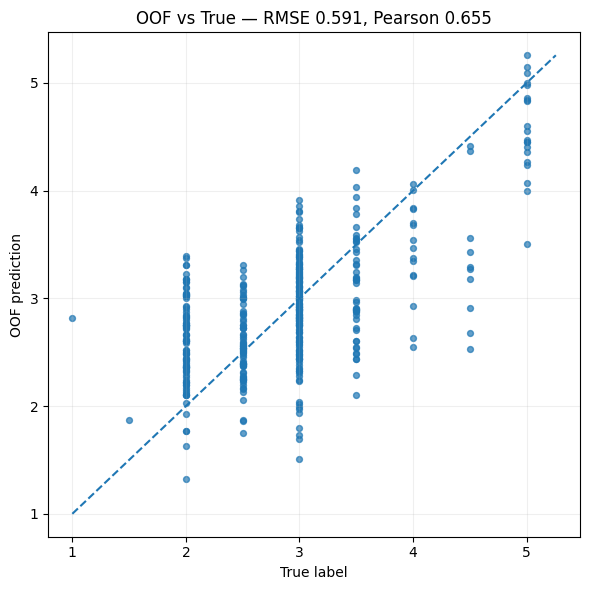

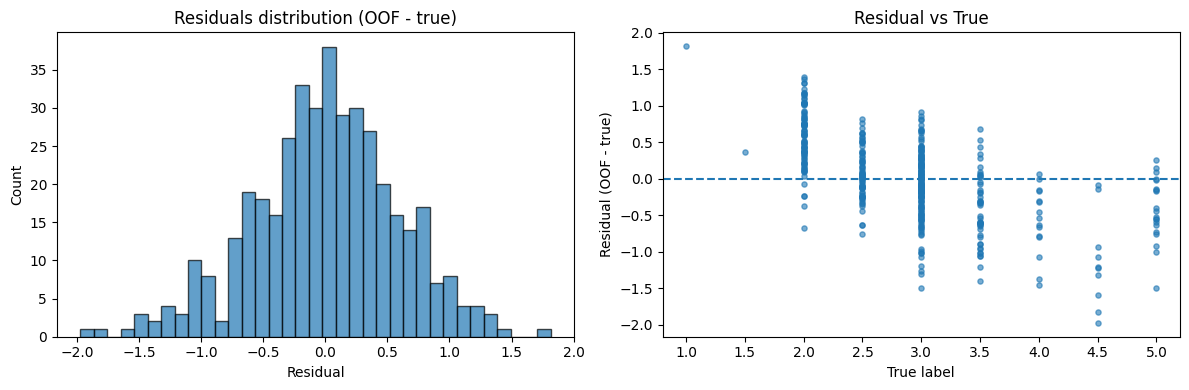

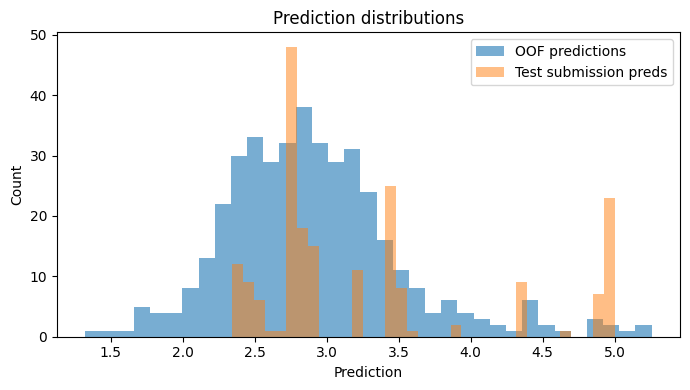

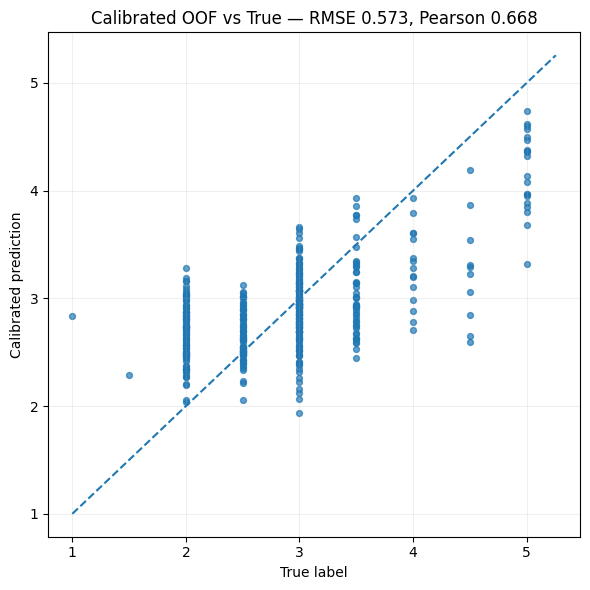

Saved markdown summary -> /kaggle/working/final_visualization_summary.md


In [26]:
# Final visualizations & summary 

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

# -------------------------
# 0) Quiet the noisy outputs
# -------------------------
# many GPU/transformer messages come through stderr; we can reduce Python warnings shown here:
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # TensorFlow logs (if any)
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
# NOTE: some low-level C++ CUDA messages cannot be fully suppressed from Python.
# -------------------------

OUT_DIR = "/kaggle/working"

candidate_oof_files = [
    "oof_1.npy", "oof_2.npy", "oof_3.npy", "oof_4.npy", "oof_5.npy",
    "oof_ridge_wavlm_step3.npy", "oof_lgb_wavlm_step3.npy", "oof_xgb_wavlm_step3.npy",
    "oof_blend_step5.npy", "oof_blend_shrink_step5.npy", "oof_stack_wavlm_step3.npy"
]

# Prefer a stacked OOF  (shape (n, k)), else try to load a single OOF vector that represents the final stack.
oof = None
found = []
for f in candidate_oof_files:
    p = os.path.join(OUT_DIR, f)
    if os.path.exists(p):
        try:
            arr = np.load(p, allow_pickle=True)
            found.append((f, arr.shape))
            # pick first 1-d array named like final stack candidates, prefer 'oof_stack...' or 'oof_blend...'
            if oof is None:
                if arr.ndim == 1:
                    oof = arr
                elif arr.ndim == 2 and arr.shape[1] in (2,3,4,5):  # stacked oof matrix -> reduce to mean prediction
                    oof = arr.mean(axis=1)
        except Exception as e:
            # not a numpy array or can't load - skip
            pass

# If we still don't have oof but there exists an oof_stack file saved under standardized name:
if oof is None:
    alt = os.path.join(OUT_DIR, "oof_stack_wavlm_step3.npy")
    if os.path.exists(alt):
        oof = np.load(alt).mean(axis=1)

if oof is None:
    raise FileNotFoundError("No suitable OOF array found in /kaggle/working. Check file names and re-run this cell.")

# Try loading the true labels from train.csv
train_csv = "/kaggle/input/shl-intern-hiring-assessment-2025/dataset/csvs/train.csv"
if os.path.exists(train_csv):
    df_train = pd.read_csv(train_csv)
    y_true = df_train["label"].values
else:
    raise FileNotFoundError("train.csv not found at expected path. Please ensure dataset is available.")

# Optional: if you have a calibrated final OOF (isotonic / linear), try to load it and compare
calibrated_oof = None
calib_candidates = ["oof_blend_shrink_step5.npy", "oof_blend_step5.npy", "oof_5.npy"]
for f in calib_candidates:
    p = os.path.join(OUT_DIR, f)
    if os.path.exists(p):
        try:
            a = np.load(p)
            if a.shape == oof.shape:
                calibrated_oof = a
                break
        except:
            pass

# Compute metrics
def compute_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    pear = pearsonr(y_true, y_pred)[0]
    return rmse, pear

oof_rmse, oof_pear = compute_metrics(y_true, oof)
if calibrated_oof is not None:
    cal_rmse, cal_pear = compute_metrics(y_true, calibrated_oof)
else:
    cal_rmse, cal_pear = (None, None)

# Load final test preds if available (for distribution plots)
test_pred = None
test_candidates = ["submission_final_calibrated_iso.csv", "submission_blend_step5.csv", "submission_wavlm_step3.csv",
                   "submission_stack_final.csv", "submission_shrink_step5.csv", "submission_meta_isotonic.csv"]
for fname in test_candidates:
    p = os.path.join(OUT_DIR, fname)
    if os.path.exists(p):
        try:
            sub = pd.read_csv(p)
            if "label" in sub.columns:
                test_pred = sub["label"].values
                break
        except:
            pass

# -------------------------
# 1) Create summary table (DataFrame)
# -------------------------
rows = [
    {"name": "OOF (chosen)", "RMSE": float(oof_rmse), "Pearson": float(oof_pear)}
]
if cal_rmse is not None:
    rows.append({"name": "OOF (calibrated)", "RMSE": float(cal_rmse), "Pearson": float(cal_pear)})

summary_df = pd.DataFrame(rows).set_index("name")
print("=== OOF Summary ===")
print(summary_df)
print("\nFigures saved to /kaggle/working (plot_oof_vs_true.png, plot_residuals.png, plot_pred_dist.png, plot_calibration.png)")

# -------------------------
# 2) OOF vs True (scatter + identity)
# -------------------------
plt.figure(figsize=(6,6))
plt.scatter(y_true, oof, alpha=0.7, s=18)
mn = min(y_true.min(), oof.min())
mx = max(y_true.max(), oof.max())
plt.plot([mn,mx],[mn,mx], linestyle="--")
plt.xlabel("True label")
plt.ylabel("OOF prediction")
plt.title(f"OOF vs True — RMSE {oof_rmse:.3f}, Pearson {oof_pear:.3f}")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_oof_vs_true.png"), dpi=150)
plt.show()

# -------------------------
# 3) Residuals: histogram + jittered scatter residual vs true
# -------------------------
residuals = oof - y_true
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].hist(residuals, bins=35, edgecolor="k", alpha=0.7)
ax[0].set_title("Residuals distribution (OOF - true)")
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Count")

ax[1].scatter(y_true, residuals, s=14, alpha=0.6)
ax[1].axhline(0, linestyle="--")
ax[1].set_xlabel("True label")
ax[1].set_ylabel("Residual (OOF - true)")
ax[1].set_title("Residual vs True")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_residuals.png"), dpi=150)
plt.show()

# -------------------------
# 4)  Prediction distributions (train OOF and test submission if available)
# -------------------------
plt.figure(figsize=(7,4))
plt.hist(oof, bins=35, alpha=0.6, label="OOF predictions", density=False)
if test_pred is not None:
    plt.hist(test_pred, bins=35, alpha=0.5, label="Test submission preds")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.legend()
plt.title("Prediction distributions")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_pred_dist.png"), dpi=150)
plt.show()

# -------------------------
# 5) plot true vs calibrated predictions if available
# -------------------------
if calibrated_oof is not None:
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, calibrated_oof, alpha=0.7, s=18)
    plt.plot([mn,mx],[mn,mx], linestyle="--")
    plt.xlabel("True label")
    plt.ylabel("Calibrated prediction")
    plt.title(f"Calibrated OOF vs True — RMSE {cal_rmse:.3f}, Pearson {cal_pear:.3f}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "plot_calibration.png"), dpi=150)
    plt.show()

# -------------------------
# 6) Save a short markdown summary for notebook (human-friendly)
# -------------------------
md_path = os.path.join(OUT_DIR, "final_visualization_summary.md")
with open(md_path, "w") as f:
    f.write("# Final results visualizations\n\n")
    f.write("**OOF Summary**\n\n")
    f.write(summary_df.to_markdown() + "\n\n")
    f.write("Figures saved:\n\n")
    f.write("- plot_oof_vs_true.png — scatter OOF vs true (identity line)\n")
    f.write("- plot_residuals.png — residual histogram + residual vs true\n")
    f.write("- plot_pred_dist.png — prediction distributions (OOF and test submission)\n")
    if calibrated_oof is not None:
        f.write("- plot_calibration.png — calibrated OOF vs true\n")
    f.write("\nThis file was generated automatically. Use these figures in your final notebook section 'Results & Discussion'.\n")

print("Saved markdown summary ->", md_path)